In [223]:
# ============================================================================
# IMPORTS & CONFIG
# ============================================================================

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import geopandas as gpd
import numpy as np


In [224]:
# ============================================================================
# Chargement & Préparation des données
# ============================================================================

bornes = pd.read_csv("../data/raw/BornesPropres.csv", low_memory=False) 
vehicules = pd.read_csv("../data/raw/voitures_par_commune_cleaned.csv", low_memory=False)
population = pd.read_csv("../data/clean/population_with_geopoint.csv", low_memory=False)

# dates et types
bornes["date_mise_en_service"] = pd.to_datetime(bornes["date_mise_en_service"], errors="coerce")

vehicules["code_commune"] = vehicules["code_commune"].astype(str).str.zfill(5)  # code commune sur 5 chiffres
vehicules["date_recensement"] = pd.to_datetime(vehicules["date_recensement"], errors="coerce") # date
vehicules["departement"] = vehicules["departement"].astype(str).str.strip().str.upper() # departement
vehicules["nb_voit_elec"] = pd.to_numeric(vehicules["nb_voit_elec"], errors="coerce") # nb voitures elec
vehicules["nb_voit_total"] = pd.to_numeric(vehicules["nb_voit_total"], errors="coerce") # nb voitures

# population
population["departement"] = population["Département"].astype(str).str.strip().str.upper() # departement

cols_to_num = [
    "0 à 19 ans", "20 à 39 ans", "40 à 59 ans",
    "60 à 74 ans", "75 ans et plus", "Total"
]

for col in cols_to_num:
    population[col] = (
        population[col]
        .astype(str)                              # force en string pour nettoyage
        .str.replace(r"\s", "", regex=True)       # supprime tous les espaces
        .str.replace(",", ".", regex=False)       # remplace les virgules par des points si besoin
        .replace({"-": None, "nc": None})         # gère les valeurs non numériques
        .astype(float)                            # convertit en float
    )


# Nouvelles colonnes dates (annee, mois, jour)

def extraire_date_datetime(df, colonne_date, prefix=""):
    """
    Crée des colonnes 'annee', 'mois', 'jour' en type datetime.date à partir d'une colonne datetime.
    prefix : préfixe pour les nouvelles colonnes
    """
    col_prefix = f"_{prefix}" if prefix else ""
    df[f'annee{col_prefix}'] = pd.to_datetime(df[colonne_date]).dt.year.astype('Int64')
    df[f'mois{col_prefix}'] = pd.to_datetime(df[colonne_date]).dt.month.astype('Int64')
    df[f'jour{col_prefix}'] = pd.to_datetime(df[colonne_date]).dt.day.astype('Int64')
    df[f'date{col_prefix}'] = pd.to_datetime(df[colonne_date]).dt.date  # version date
    return df

# Application aux bornes et véhicules
bornes = extraire_date_datetime(bornes, 'date_mise_en_service', prefix='mes')
vehicules = extraire_date_datetime(vehicules, 'date_recensement', prefix='recensement')

# print(bornes.dtypes)
# print(vehicules.dtypes)

In [225]:
# ============================================================================
# Jointure VEHICULES & POPULATION
# ============================================================================

# Vérifier les départements communs
set_pop = set(population['departement'].unique())
set_vehicules = set(vehicules['departement'].unique())
print("Départements communs population / véhicules :", len(set_pop & set_vehicules))

# Effectuer la jointure
vehicule_pop = vehicules.merge(
    population,
    on='departement',
    how='inner'  # inner = seulement les départements présents dans les deux jeux
)

print(vehicule_pop.head())

Départements communs population / véhicules : 94
  code_commune           nom_commune           id_unique_commune departement  \
0        34045             cabrières             CABRIÈRES_34045     HÉRAULT   
1        34046  cambon-et-salvergues  CAMBON-ET-SALVERGUES_34046     HÉRAULT   
2        34046  cambon-et-salvergues  CAMBON-ET-SALVERGUES_34046     HÉRAULT   
3        34047             campagnan             CAMPAGNAN_34047     HÉRAULT   
4        34047             campagnan             CAMPAGNAN_34047     HÉRAULT   

      region date_recensement  nb_voit_elec  nb_voit_total  annee_recensement  \
0  Occitanie       2024-03-31            10            647               2024   
1  Occitanie       2022-09-30             0             63               2022   
2  Occitanie       2025-03-31             0             73               2025   
3  Occitanie       2023-12-31            14            888               2023   
4  Occitanie       2025-03-31            21            899       

In [226]:
# ============================================================================
# Jointure BORNES & POPULATION
# ============================================================================

# --- Nettoyage BORNES ---

# Création GeoDataFrames en WGS84
gdf_bornes = gpd.GeoDataFrame(
    bornes,
    geometry=gpd.points_from_xy(bornes['consolidated_longitude'], bornes['consolidated_latitude']),
    crs="EPSG:4326"
)

gdf_population = gpd.GeoDataFrame(
    population,
    geometry=gpd.points_from_xy(population['longitude_decimal'], population['latitude_decimal']),
    crs="EPSG:4326"
)

# Reprojection dans Lambert 93 (mètres) pour distance en mètres
gdf_bornes = gdf_bornes.to_crs(2154)
gdf_population = gdf_population.to_crs(2154)


# ---  Jointure par proximité ---
bornes_pop = gpd.sjoin_nearest(
    gdf_bornes,
    gdf_population,
    how='left',
    max_distance=60000,
    rsuffix='_pop'  # suffixe ajouté pour les colonnes du gdf_population
)

# print(bornes_pop.columns)
print(bornes_pop['departement'].head())


0    BAS-RHIN
1    BAS-RHIN
2    BAS-RHIN
3    BAS-RHIN
4    BAS-RHIN
Name: departement, dtype: object


In [227]:
# --- Diagnostic : bornes sans correspondance ---
bornes_sans_pop = bornes_pop[bornes_pop['Total'].isna()]

print(f"Bornes totales : {len(bornes_pop)}")
print(f"Bornes sans correspondance : {len(bornes_sans_pop)} "
      f"({len(bornes_sans_pop)/len(bornes_pop)*100:.1f}%)")

# Extraction des coordonnées x et y depuis la colonne geometry
bornes_sans_pop = bornes_sans_pop.assign(
    x=bornes_sans_pop.geometry.x,
    y=bornes_sans_pop.geometry.y
)

print("\nAperçu des bornes sans correspondance :")
print(bornes_sans_pop[['x', 'y']].head())

Bornes totales : 163930
Bornes sans correspondance : 3016 (1.8%)

Aperçu des bornes sans correspondance :
                  x             y
2915  899043.614639  6.936323e+06
4986  337366.978081  6.275663e+06
4987  337367.167130  6.275662e+06
4988  337366.978081  6.275663e+06
4989  337367.167130  6.275662e+06


In [228]:
# Extraction des colonnes utiles pour le calcul des bornes par 1000 hab
pop_dep = population.groupby('departement')['Total'].sum().reset_index()

In [ ]:
# Créer de nouvelles colonnes pour analyse & charts

# ⚠️ nbre_pdc cumulatif et split annee + mois

# --- Regrouper par année-mois et récupérer le total cumulatif maximal par mois --- ❌
bornes_mois = (
    bornes.groupby('annee_mes')['nbre_pdc']
    .max()
    .reset_index()
)

# --- Calculer les nouvelles bornes comme différence par rapport au mois précédent ---
bornes_mois['nouvelles_bornes'] = bornes_mois['nbre_pdc'].diff().fillna(bornes_mois['nbre_pdc']).astype(int)

# --- Cumul total des bornes ---
bornes_mois['bornes_cumulees'] = bornes_mois['nouvelles_bornes'].cumsum().astype(int)

# --- Merge avec bornes_pop pour ajouter la colonne nouvelles_bornes ---
bornes_pop = bornes_pop.assign(
    nouvelles_bornes = bornes_pop['annee_mes'].map(
        bornes_mois.set_index('annee_mes')['nouvelles_bornes']
    )
)

print(bornes_mois.head())


   annee_mes  nbre_pdc  nouvelles_bornes  bornes_cumulees
0       1900         1                 1                1
1       1930         2                 1                2
2       2002         8                 6                8
3       2010         4                -4                4
4       2012         8                 4                8


In [ ]:
# --- Création d'un DataFrame df_ve depuis vehicule_pop ---
# ⚠️

# On agrège par année le nombre total de VE
df_ve = (
    vehicule_pop.groupby('annee_recensement')['nb_voit_elec']
    .sum()
    .reset_index()
    .rename(columns={'annee_recensement': 'annee', 'nb_voit_elec': 'nb_ve'})
)

# Vérifions
print(df_ve.head())

# --- Création de df_correlations --- MAJ

# Somme des bornes par département
bornes_par_dep = bornes_pop.groupby('departement')['nbre_pdc'].sum().reset_index()

# Nombre de VE par département
ve_par_dep = vehicule_pop.groupby('departement')['nb_voit_elec'].sum().reset_index()

# Merge pour préparer df_correlations
df_correlations = bornes_par_dep.merge(ve_par_dep, on='departement', how='left')
df_correlations = df_correlations.merge(pop_dep, on='departement', how='left')

# Calcul bornes pour 1000 habitants
df_correlations['bornes_pour_1000_hab'] = df_correlations['nbre_pdc'] / df_correlations['Total'] * 1000


# Vérification
print(df_correlations.head())


   annee    nb_ve
0   2020   369704
1   2021  2138953
2   2022  3319949
3   2023  4805690
4   2024  6508973
               departement  nbre_pdc  nb_voit_elec      Total  \
0                      AIN      6054      256580.0   688626.0   
1                    AISNE      7864      174540.0   518817.0   
2                   ALLIER      5236       76010.0   332599.0   
3  ALPES-DE-HAUTE-PROVENCE      3177       52949.0   169806.0   
4          ALPES-MARITIMES     24069      541995.0  1129950.0   

   bornes_pour_1000_hab  
0              8.791419  
1             15.157560  
2             15.742681  
3             18.709586  
4             21.300943  


In [231]:
# --- Création de df_correlations ---
# df_correlations = (
#    bornes_pop.groupby('departement')['nbre_pdc'].sum().reset_index()
#    .rename(columns={'nbre_pdc': 'total_bornes'})
#)

# Ajouter le nombre de VE par département
#ve_par_dep = vehicule_pop.groupby('departement')['nb_voit_elec'].sum().reset_index()
#df_correlations = df_correlations.merge(ve_par_dep, on='departement', how='left')

# Calcul bornes pour 1000 habitants
#pop_dep = population.groupby('departement')['Total'].sum().reset_index()
#df_correlations = df_correlations.merge(pop_dep, on='departement', how='left')
#df_correlations['bornes_pour_1000_hab'] = df_correlations['total_bornes'] / df_correlations['Total'] * 1000

In [232]:
# ============================================================================ 
# 2. FONCTIONS D'ANALYSE (MAJ) + texte
# ============================================================================ 

def analyse_automatique(df_ve, df_bornes, df_correlations):
    """
    Génère un texte d'analyse automatique basé sur les données VE, bornes et corrélations.
    df_bornes doit contenir la colonne 'nouvelles_bornes' et 'bornes_cumulees'.
    """
    # --- 1. Tendances VE ---
    croissance_ve = (df_ve['nb_ve'].iloc[-1] - df_ve['nb_ve'].iloc[0]) / df_ve['nb_ve'].iloc[0] * 100
    annee_max_ve = df_ve.loc[df_ve['nb_ve'].idxmax(), 'annee']
    
    # --- 2. Tendances Bornes ---
    # Croissance sur la période basée sur le cumul des bornes
    croissance_bornes = (df_bornes['bornes_cumulees'].iloc[-1] - df_bornes['bornes_cumulees'].iloc[0]) / df_bornes['bornes_cumulees'].iloc[0] * 100
    annee_max_bornes = df_bornes.loc[df_bornes['bornes_cumulees'].idxmax(), 'annee_mes']
    
    # --- 3. Ratio Bornes/VE ---
    ratio_bornes_ve = df_bornes['bornes_cumulees'].iloc[-1] / df_ve['nb_ve'].iloc[-1]
    
    # --- 4. Corrélation ---
    corr = df_correlations['bornes_pour_1000_hab'].corr(df_correlations['nb_voit_elec'])
    
    # --- 5. Détection des disparités ---
    top_dep = df_correlations.sort_values('bornes_pour_1000_hab', ascending=False).head(3)
    flop_dep = df_correlations.sort_values('bornes_pour_1000_hab', ascending=True).head(3)
    
    # --- 6. Génération du texte ---
    texte = f"""
    📊 **Analyse Automatique - Infrastructures VE en France**

    1️⃣ **Parc de véhicules électriques**
    - Croissance sur la période : **+{croissance_ve:.1f}%**
    - Année record en immatriculations : **{annee_max_ve}**
    → Le marché est en forte progression, porté par les aides et l'offre croissante des constructeurs.

    2️⃣ **Bornes de recharge**
    - Croissance sur la période : **+{croissance_bornes:.1f}%**
    - Mois record en déploiement : **{annee_max_bornes}**
    - Ratio actuel bornes/VE : **1 borne pour {1/ratio_bornes_ve:.1f} VE**
    → Le déploiement suit la tendance des ventes, mais le ratio reste inférieur aux recommandations européennes.

    3️⃣ **Corrélation**
    - Corrélation bornes ↔ VE : **{corr:.2f}**
    → Une corrélation positive indique que les départements les mieux équipés en bornes tendent à avoir plus de VE.

    4️⃣ **Disparités territoriales**
    - Top 3 départements les mieux équipés (bornes/1000 hab) : {', '.join(top_dep['departement'])}
    - Flop 3 les moins équipés : {', '.join(flop_dep['departement'])}
    → Les disparités régionales restent marquées, nécessitant des efforts ciblés.

    💡 **Recommandations**
    - Accélérer le déploiement dans les zones à faible couverture (notamment {', '.join(flop_dep['departement'])}). 
    - Adapter le rythme d’installation des bornes à la croissance attendue des VE pour maintenir un ratio optimal.
    - Encourager l’installation de bornes rapides dans les zones à fort trafic.
    """

    return texte

# --- Appel de la fonction ---
analyse_text = analyse_automatique(df_ve, bornes_mois, df_correlations)

# Affichage Markdown dans le notebook
from IPython.display import Markdown, display
display(Markdown(analyse_text))


    📊 **Analyse Automatique - Infrastructures VE en France**

    1️⃣ **Parc de véhicules électriques**
    - Croissance sur la période : **+930.4%**
    - Année record en immatriculations : **2024**
    → Le marché est en forte progression, porté par les aides et l'offre croissante des constructeurs.

    2️⃣ **Bornes de recharge**
    - Croissance sur la période : **+0.0%**
    - Mois record en déploiement : **2022**
    - Ratio actuel bornes/VE : **1 borne pour 3809310.0 VE**
    → Le déploiement suit la tendance des ventes, mais le ratio reste inférieur aux recommandations européennes.

    3️⃣ **Corrélation**
    - Corrélation bornes ↔ VE : **-0.04**
    → Une corrélation positive indique que les départements les mieux équipés en bornes tendent à avoir plus de VE.

    4️⃣ **Disparités territoriales**
    - Top 3 départements les mieux équipés (bornes/1000 hab) : PARIS, SEINE-SAINT-DENIS, HAUTS-DE-SEINE
    - Flop 3 les moins équipés : HAUTE-CORSE, HAUTE-SAÔNE, SEINE-ET-MARNE
    → Les disparités régionales restent marquées, nécessitant des efforts ciblés.

    💡 **Recommandations**
    - Accélérer le déploiement dans les zones à faible couverture (notamment HAUTE-CORSE, HAUTE-SAÔNE, SEINE-ET-MARNE). 
    - Adapter le rythme d’installation des bornes à la croissance attendue des VE pour maintenir un ratio optimal.
    - Encourager l’installation de bornes rapides dans les zones à fort trafic.
    

In [233]:
# ============================================================================ 
# FONCTIONS D'ANALYSE PRÊTES À L'EMPLOI (MAJ)
# ============================================================================

def calcul_kpi_croissance(df, col_valeur, col_temps):
    """Croissance totale (%) sur la période min-max"""
    if len(df) > 1:
        croissance = ((df[col_valeur].iloc[-1] - df[col_valeur].iloc[0]) /
                      df[col_valeur].iloc[0]) * 100
        periode = (df[col_temps].min(), df[col_temps].max())
        return croissance, periode
    return None, None

def calcul_nouvelles_bornes_12m(df, col_cumule='bornes_cumulees', col_nouvelles='nouvelles_bornes'):
    """Total bornes et nouvelles bornes sur 12 derniers mois"""
    if len(df) > 1:
        total = df[col_cumule].iloc[-1]
        nouvelles_12m = df[col_nouvelles].tail(12).sum() if len(df) >= 12 else None
        return total, nouvelles_12m
    return None, None

def calcul_corr(df, col_x, col_y):
    """Corrélation entre deux colonnes"""
    return df[[col_x, col_y]].corr().iloc[0,1]

def afficher_resume(vehicule_pop, bornes_pop, population):
    """Résumé statistique complet basé sur les jointures"""

    print("\n" + "="*50)
    print("📊 RÉSUMÉ DES ANALYSES")
    print("="*50)

    # --- Croissance VE ---
    df_ve = vehicule_pop.groupby('annee_recensement')['nb_voit_elec'].sum().reset_index()
    croissance_ve, periode_ve = calcul_kpi_croissance(df_ve, 'nb_voit_elec', 'annee_recensement')
    if croissance_ve is not None:
        print(f"🚗 Croissance VE totale : +{croissance_ve:.1f}%")
        print(f"📅 Période analysée VE : {periode_ve[0]}-{periode_ve[1]}")

    # --- Bornes ---
    bornes_mois = bornes_pop.groupby('annee_mes')['nbre_pdc'].sum().reset_index()
    bornes_mois['nouvelles_bornes'] = bornes_mois['nbre_pdc'].diff().fillna(bornes_mois['nbre_pdc'])
    bornes_mois['bornes_cumulees'] = bornes_mois['nouvelles_bornes'].cumsum()
    
    total_bornes, nouvelles_12m = calcul_nouvelles_bornes_12m(bornes_mois)
    if total_bornes is not None:
        print(f"🔌 Total bornes déployées : {int(total_bornes):,}")
        if nouvelles_12m is not None:
            print(f"📈 Nouvelles bornes (12 derniers mois) : {int(nouvelles_12m):,}")

    # --- Corrélations ---
    # Préparer df_correlations
    pop_dep = population.groupby('departement')['Total'].sum().reset_index()
    bornes_par_dep = bornes_pop.groupby('departement')['nbre_pdc'].sum().reset_index()
    ve_par_dep = vehicule_pop.groupby('departement')['nb_voit_elec'].sum().reset_index()

    df_correlations = bornes_par_dep.merge(ve_par_dep, on='departement', how='left')
    df_correlations = df_correlations.merge(pop_dep, on='departement', how='left')
    df_correlations['bornes_pour_1000_hab'] = df_correlations['nbre_pdc'] / df_correlations['Total'] * 1000

    corr_pop_bornes = calcul_corr(df_correlations, 'Total', 'nbre_pdc')
    corr_ve_bornes = calcul_corr(df_correlations, 'nb_voit_elec', 'nbre_pdc')

    print(f"🔗 Corrélation Population/Bornes : {corr_pop_bornes:.3f}")
    print(f"⚡ Corrélation VE/Bornes : {corr_ve_bornes:.3f}")
    print(f"📊 Départements analysés : {vehicule_pop['departement'].nunique()}")
    print("\n✅ Résumé complet généré !")


# ============================================================================ 
# Appel de la fonction avec affichage
# ============================================================================

# Appel de la fonction
afficher_resume(vehicule_pop, bornes_pop, population)


📊 RÉSUMÉ DES ANALYSES
🚗 Croissance VE totale : +930.4%
📅 Période analysée VE : 2020-2025
🔌 Total bornes déployées : 5
📈 Nouvelles bornes (12 derniers mois) : -2,189
🔗 Corrélation Population/Bornes : 0.498
⚡ Corrélation VE/Bornes : 0.122
📊 Départements analysés : 94

✅ Résumé complet généré !


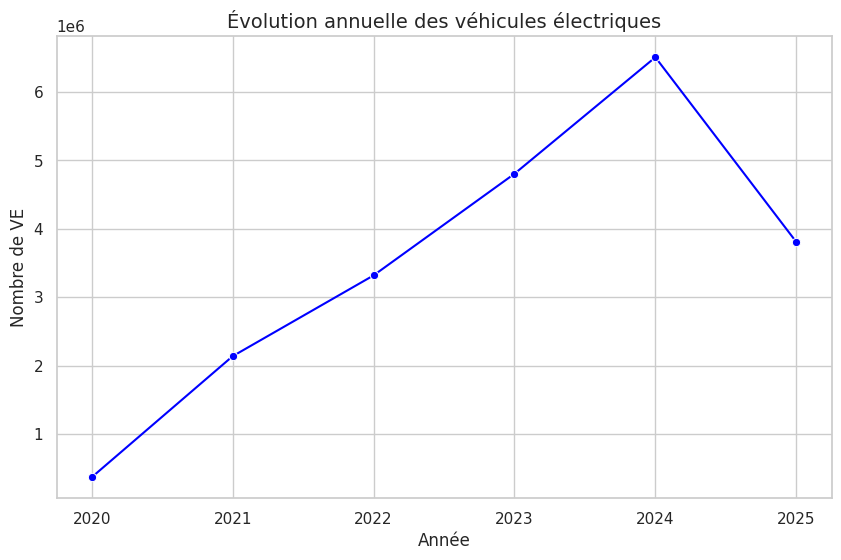

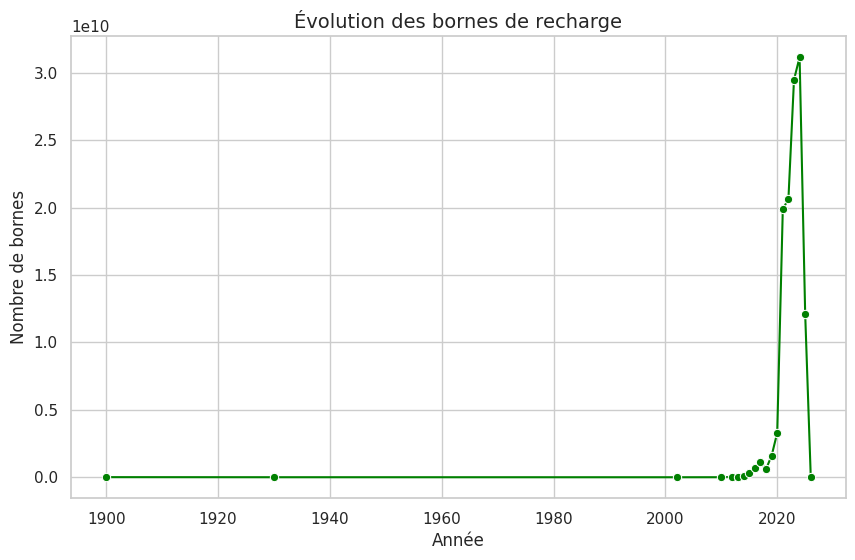

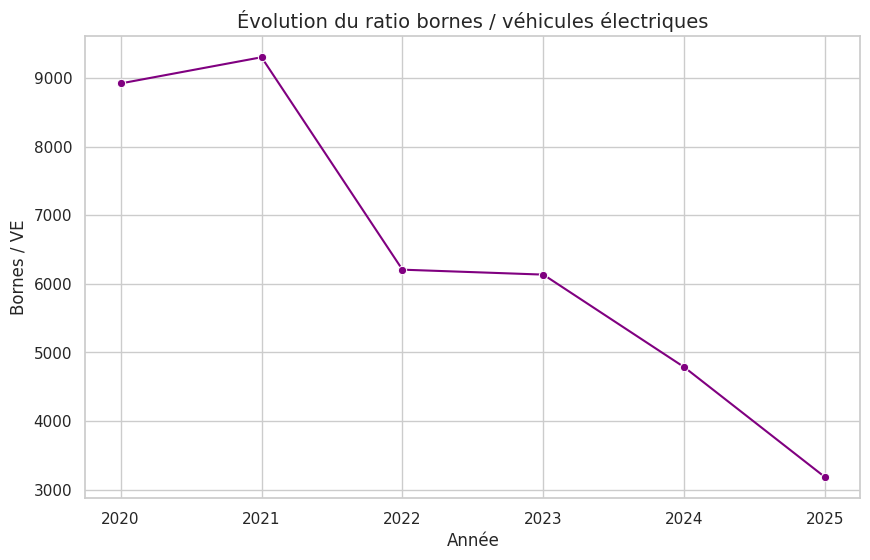

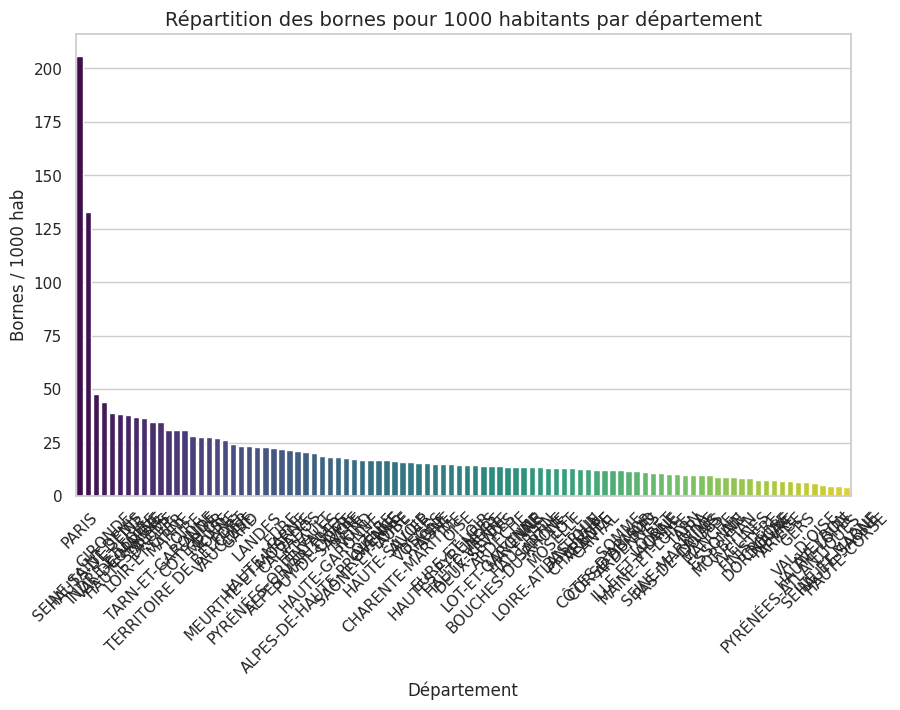

In [234]:
# ============================================================================ 
# 3. VISUALISATIONS PRINCIPALES (MAJ3) 
# ============================================================================

def plot_evolution_ve(vehicule_pop):
    col_annee = 'annee_recensement'
    
    if col_annee in vehicule_pop.columns and 'nb_voit_elec' in vehicule_pop.columns:
        df = vehicule_pop.groupby(col_annee)['nb_voit_elec'].sum().reset_index().dropna()
        if not df.empty:
            sns.lineplot(data=df, x=col_annee, y="nb_voit_elec", marker="o", color="blue")
            plt.title("Évolution annuelle des véhicules électriques")
            plt.xlabel("Année")
            plt.ylabel("Nombre de VE")
            plt.show()
        else:
            print("⚠️ df vide après groupby pour plot_evolution_ve")
    else:
        print(f"⚠️ Colonnes manquantes pour plot_evolution_ve : {col_annee}, nb_voit_elec")

plot_evolution_ve(vehicule_pop)
plt.show()

def plot_evolution_bornes(bornes_pop):
    col_annee = 'annee_mes' 
    col_cumule = 'Total'
    
    if col_annee in bornes_pop and col_cumule in bornes_pop:
        df = bornes_pop.groupby(col_annee)[col_cumule].sum().reset_index().dropna()
        if not df.empty:
            sns.lineplot(data=df, x=col_annee, y=col_cumule, marker="o", color="green")
            plt.title("Évolution des bornes de recharge")
            plt.xlabel("Année")
            plt.ylabel("Nombre de bornes")
            plt.show()
        else:
            print("⚠️ df vide après groupby pour plot_evolution_bornes")
    else:
        print(f"⚠️ Colonnes manquantes pour plot_evolution_bornes : {col_annee}, {col_cumule}")

plot_evolution_bornes(bornes_pop)
plt.show()

def plot_ratio_bornes_ve(vehicule_pop, bornes_pop):
    col_annee_veh = 'annee_recensement' 
    col_annee_bornes = 'annee_mes'
    col_cumule_bornes = 'bornes_cumulees' if 'bornes_cumulees' in bornes_pop.columns else 'Total'
    
    df_ve = vehicule_pop.groupby(col_annee_veh)['nb_voit_elec'].sum().reset_index()
    df_bornes = bornes_pop.groupby(col_annee_bornes)[col_cumule_bornes].sum().reset_index()
    
    df = df_ve.merge(df_bornes, left_on=col_annee_veh, right_on=col_annee_bornes, how='inner')
    
    if not df.empty:
        df['ratio_bornes_ve'] = df[col_cumule_bornes] / df['nb_voit_elec']
        sns.lineplot(data=df, x=col_annee_veh, y='ratio_bornes_ve', marker="o", color="purple")
        plt.title("Évolution du ratio bornes / véhicules électriques")
        plt.xlabel("Année")
        plt.ylabel("Bornes / VE")
        plt.show()
    else:
        print("⚠️ df vide après merge pour plot_ratio_bornes_ve")

plot_ratio_bornes_ve(vehicule_pop, bornes_pop)
plt.show()

def plot_distribution_bornes_par_dep(df_correlations):
    col_bornes = 'bornes_pour_1000_hab' if 'bornes_pour_1000_hab' in df_correlations.columns else 'nouvelles_bornes'
    col_dep = 'departement' if 'departement' in df_correlations.columns else df_correlations.columns[0]
    
    if col_bornes in df_correlations.columns and col_dep in df_correlations.columns:
        sns.barplot(data=df_correlations.sort_values(col_bornes, ascending=False), x=col_dep, y=col_bornes, palette="viridis")
        plt.xticks(rotation=45)
        plt.title("Répartition des bornes pour 1000 habitants par département")
        plt.xlabel("Département")
        plt.ylabel("Bornes / 1000 hab")
        plt.show()
    else:
        print(f"⚠️ Colonnes manquantes pour plot_distribution_bornes_par_dep : {col_dep}, {col_bornes}")

plot_distribution_bornes_par_dep(df_correlations)
plt.show()


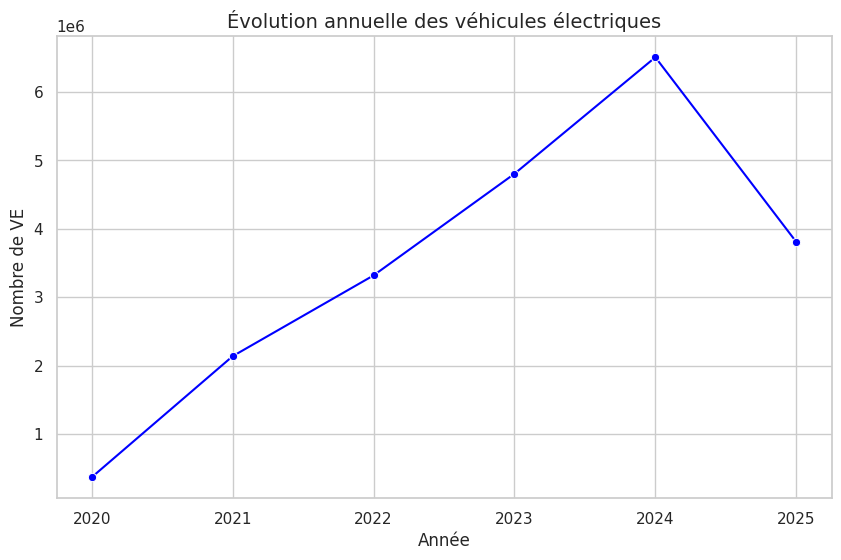

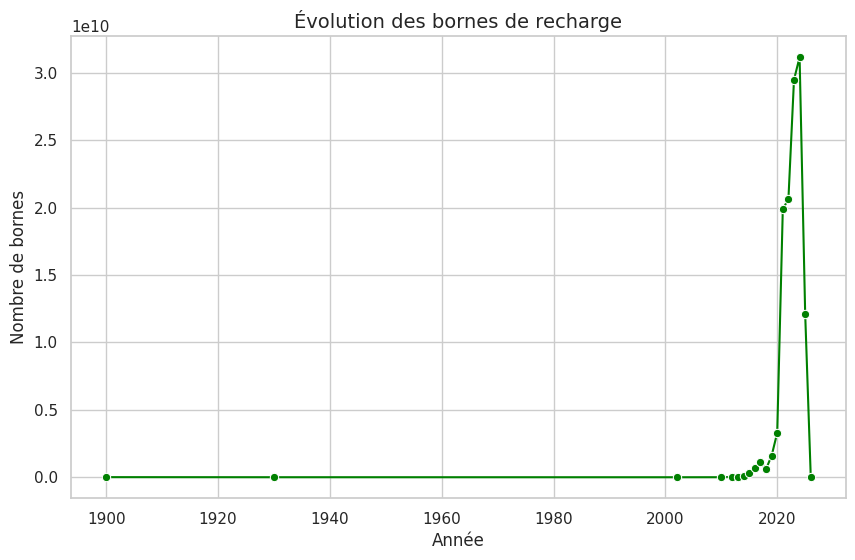

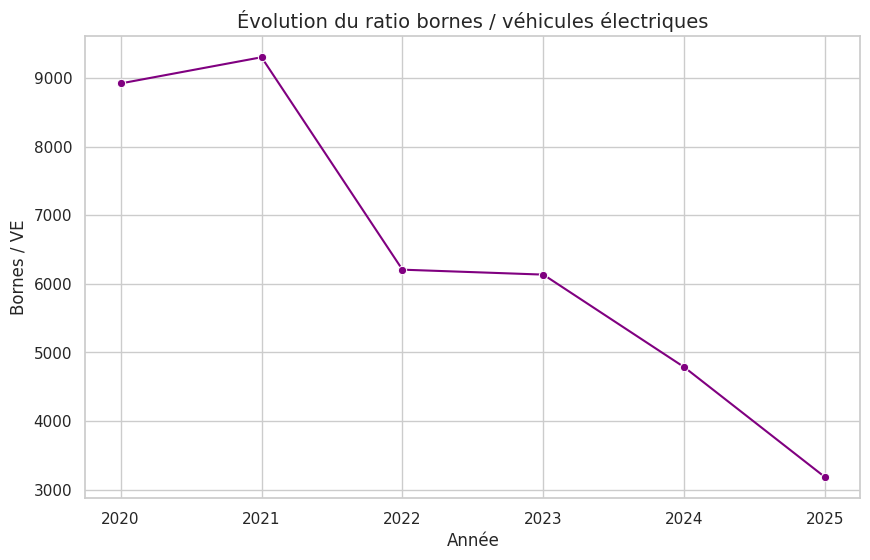

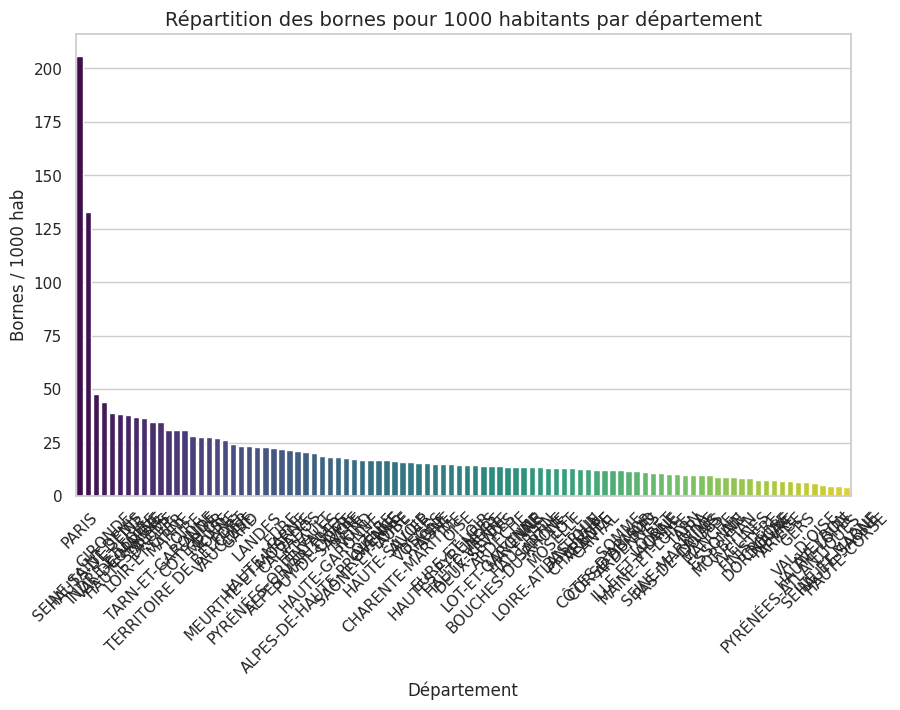

NameError: name 'evolution_ve_annuelle' is not defined

In [235]:
# ============================================================================
# 4. EXÉCUTION COMPLÈTE
# ============================================================================

# Graphiques
plot_evolution_ve(vehicule_pop)
plot_evolution_bornes(bornes_pop)
plot_ratio_bornes_ve(vehicule_pop, bornes_pop)
plot_distribution_bornes_par_dep(df_correlations)
plt.show()


plot_evolution_ve(evolution_ve_annuelle)
plot_nouvelles_bornes(nouvelles_bornes_mois)
plot_corr_pop_bornes(df_correlations)
plot_corr_ve_bornes(df_correlations)

# Résumé
afficher_resume(
    evolution_ve_annuelle,
    nouvelles_bornes_mois,
    correlation_pop,
    correlation_ve,
    df_correlations
)
